In [1]:
import pandas as pd

In [3]:
df_rent = pd.read_csv('/home/ubuntu/Working_Space/data/DLD_DATA/rents-2026-04-21.csv')

In [5]:
df_rent.columns

Index(['REGISTRATION_DATE', 'START_DATE', 'END_DATE', 'VERSION_EN', 'AREA_EN',
       'CONTRACT_AMOUNT', 'ANNUAL_AMOUNT', 'IS_FREE_HOLD_EN', 'ACTUAL_AREA',
       'PROP_TYPE_EN', 'PROP_SUB_TYPE_EN', 'ROOMS', 'USAGE_EN',
       'NEAREST_METRO_EN', 'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN', 'PARKING',
       'TOTAL_PROPERTIES', 'MASTER_PROJECT_EN', 'PROJECT_EN'],
      dtype='str')

In [7]:
df_rent.isna().sum()/len(df_rent)* 100

REGISTRATION_DATE       0.000000
START_DATE              0.000000
END_DATE                0.000000
VERSION_EN              0.000000
AREA_EN                 0.000000
CONTRACT_AMOUNT         0.000000
ANNUAL_AMOUNT           0.000000
IS_FREE_HOLD_EN         0.000000
ACTUAL_AREA             0.000000
PROP_TYPE_EN            0.000000
PROP_SUB_TYPE_EN        0.034643
ROOMS                  95.500987
USAGE_EN                0.000000
NEAREST_METRO_EN       15.741777
NEAREST_MALL_EN        16.852347
NEAREST_LANDMARK_EN     9.478504
PARKING                97.474608
TOTAL_PROPERTIES        0.000000
MASTER_PROJECT_EN      99.952806
PROJECT_EN             71.183922
dtype: float64

In [4]:
df_unit = df_rent[df_rent['PROP_TYPE_EN'] == "Unit"]

df_unit.columns

df_unit['PROP_SUB_TYPE_EN'].value_counts()

PROP_SUB_TYPE_EN
Flat                   160691
Labor Camps             21359
Studio                   1908
Staff Accommodation       166
Building                   28
Villa                      19
Mezzanine                   7
Arabian House               6
Penthouse                   4
Hotel                       3
Portacabin                  1
Name: count, dtype: int64

In [8]:
df_unit.isna().sum()/len(df_unit)* 100

REGISTRATION_DATE        0.000000
START_DATE               0.000000
END_DATE                 0.000000
VERSION_EN               0.000000
AREA_EN                  0.000000
CONTRACT_AMOUNT          0.000000
ANNUAL_AMOUNT            0.000000
IS_FREE_HOLD_EN          0.000000
ACTUAL_AREA              0.000000
PROP_TYPE_EN             0.000000
PROP_SUB_TYPE_EN         0.036904
ROOMS                  100.000000
USAGE_EN                 0.000000
NEAREST_METRO_EN        13.411484
NEAREST_MALL_EN         14.441007
NEAREST_LANDMARK_EN      8.147726
PARKING                100.000000
TOTAL_PROPERTIES         0.000000
MASTER_PROJECT_EN       99.948985
PROJECT_EN              72.612613
dtype: float64

In [10]:
df_unit_filtered    = df_unit[df_unit['PROP_SUB_TYPE_EN'] == 'Flat']

In [14]:
df_unit_filtered['actual_area'] = df_unit_filtered['ACTUAL_AREA']
df_unit_filtered['annual_amount'] = df_unit_filtered['ANNUAL_AMOUNT']

Plotting original distributions...


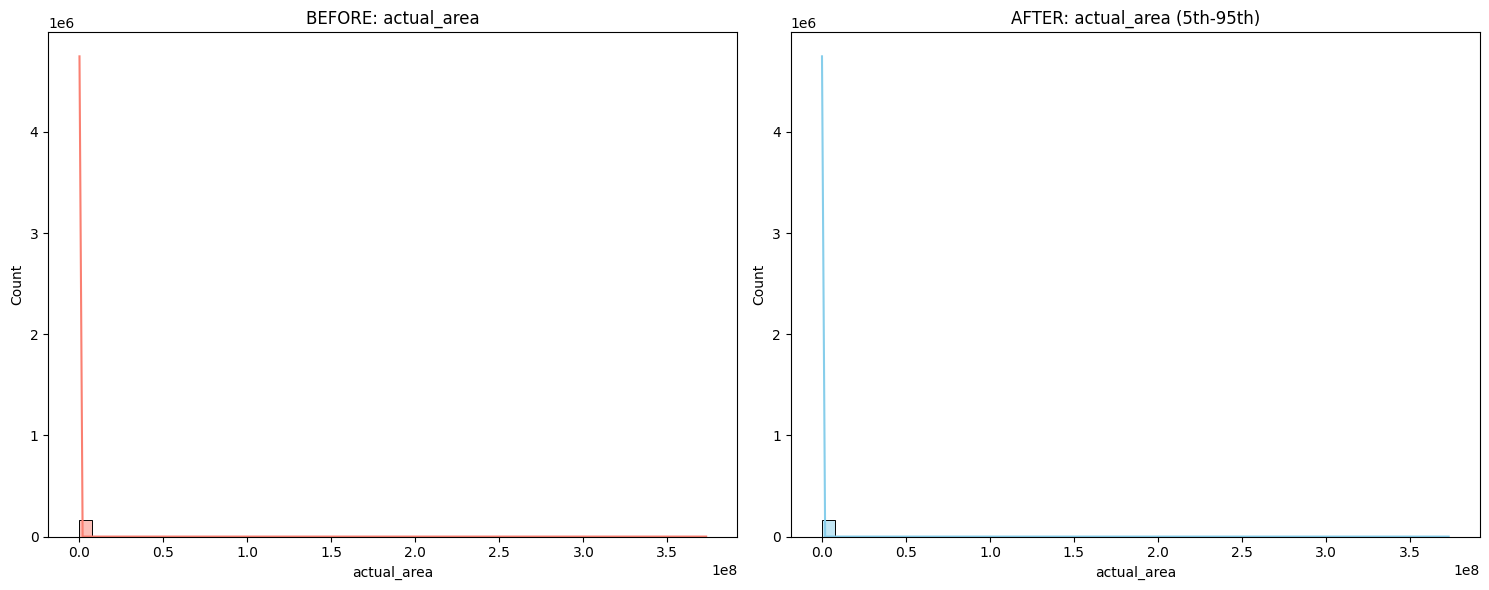

Cleaning data...
Plotting comparison...


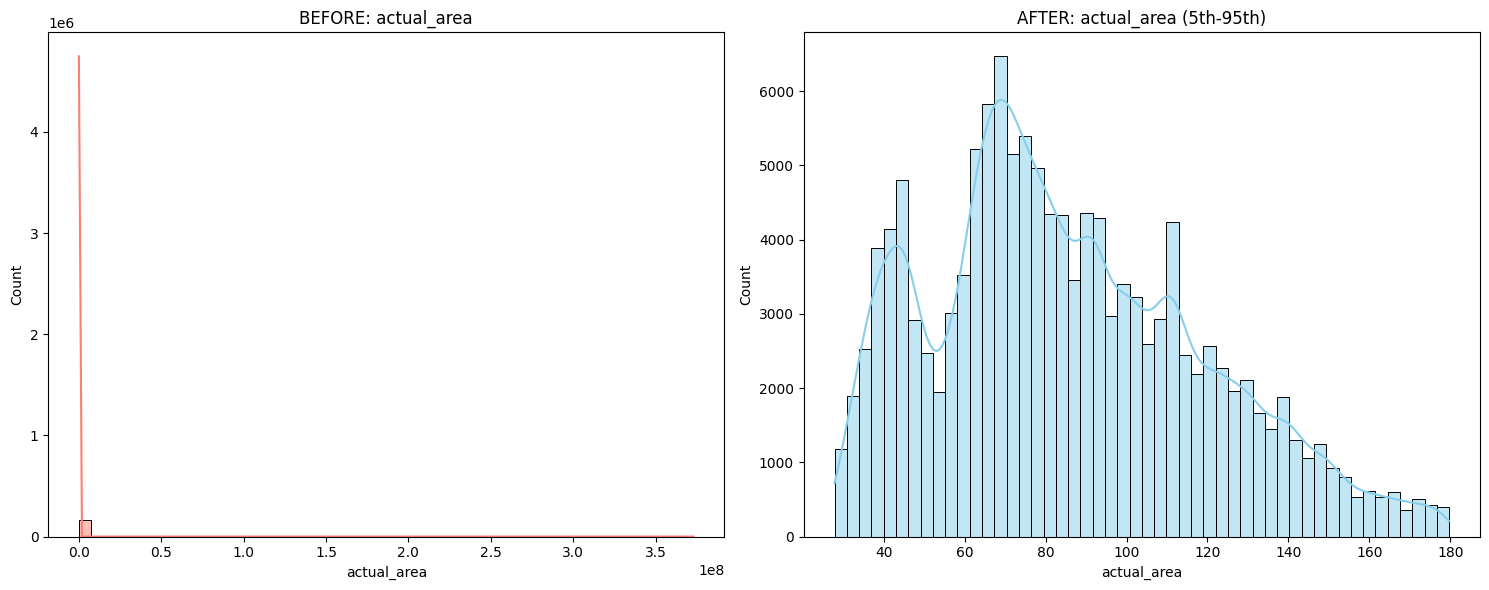

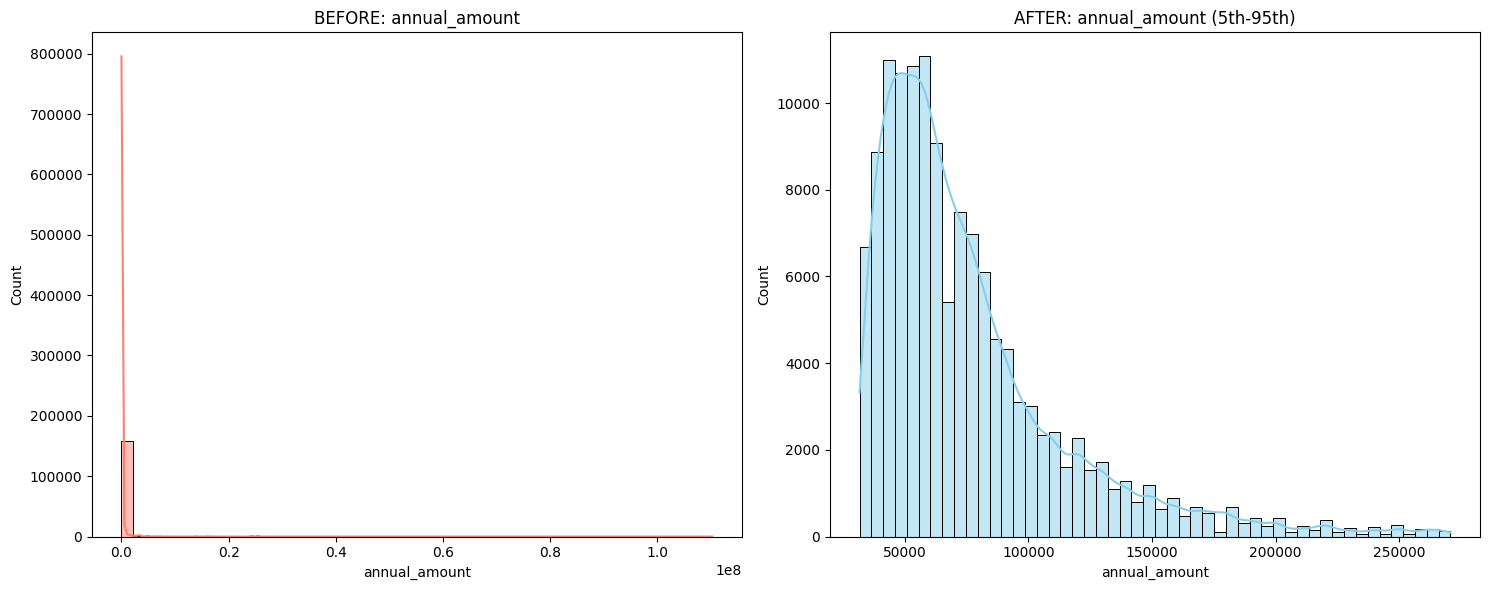

(133269, 22)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CLEANING FUNCTION (Optimized)
def clean_global(df, cols):
    df_c = df.copy()

    # Pre-clean: Remove NaNs and Infs which cause crashes in quantile math
    for col in cols:
        df_c = df_c[np.isfinite(df_c[col])]

    # Calculate limits on the stable data
    limits = {col: df_c[col].quantile([0.05, 0.95]) for col in cols}

    # Apply filters
    for col, bounds in limits.items():
        low, high = bounds[0.05], bounds[0.95]
        df_c = df_c[(df_c[col] >= low) & (df_c[col] <= high)]

    return df_c

# 2. PLOTTING FUNCTION (Memory Safe)
def plot_cleaning_comparison(df_before, df_after, col_name):
    # Use a fresh figure to prevent overlapping memory
    plt.figure(figsize=(15, 6))

    # Plot Before
    plt.subplot(1, 2, 1)
    # Using 'bins=50' prevents the plotter from creating too many bars
    sns.histplot(df_before[col_name], kde=True, color='salmon', bins=50)
    plt.title(f'BEFORE: {col_name}')

    # Plot After
    plt.subplot(1, 2, 2)
    sns.histplot(df_after[col_name], kde=True, color='skyblue', bins=50)
    plt.title(f'AFTER: {col_name} (5th-95th)')

    plt.tight_layout()
    #plt.savefig(f'dist_{col_name}.png')
    plt.show()
    plt.close() # CRITICAL: Frees up RAM after showing

# --- EXECUTION ---

# Step 1: Distribution before any cleaning (using a sample if data is huge)
# If your data is > 100k rows, use .sample(50000) for the plot to avoid crashes
print("Plotting original distributions...")
plot_cleaning_comparison(df_unit_filtered, df_unit_filtered, 'actual_area') # Logic check

# Step 2: Remove Outliers
print("Cleaning data...")
df_unit_filtered_clean = clean_global(df_unit_filtered, ['actual_area', 'annual_amount'])

# Step 3: Plot Comparison
print("Plotting comparison...")
plot_cleaning_comparison(df_unit_filtered, df_unit_filtered_clean, 'actual_area')
plot_cleaning_comparison(df_unit_filtered, df_unit_filtered_clean, 'annual_amount')

df_unit_filtered.shape

df_unit_filtered_clean.shape

In [17]:
import pandas as pd
import joblib

# 1. Load the saved files
model = joblib.load('room_classifier_model.joblib')
encoder = joblib.load('room_type_encoder.joblib')


X_new = df_unit_filtered_clean[['actual_area', 'annual_amount']]

/home/ubuntu/jupyter_env/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ubuntu/jupyter_env/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ubuntu/jupyter_env/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when u

In [18]:
# Fill any missing values so the model doesn't crash
X_new = X_new.fillna(0)

# 4. Predict
numeric_predictions = model.predict(X_new)

# 5. Convert numbers back to 'Studio', '1BHK', etc.
df_unit_filtered_clean['predicted_room_type'] = encoder.inverse_transform(numeric_predictions)

# View the result
print(df_unit_filtered_clean[['actual_area', 'annual_amount', 'predicted_room_type']].head())

   actual_area  annual_amount predicted_room_type
2        55.33        53000.0              Studio
3        96.10        68000.0                2BHK
4        33.01        50000.0              Studio
5        38.95        66000.0              Studio
6        57.00        70000.0                1BHK


/tmp/ipykernel_2892227/1587422029.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unit_filtered_clean, x='predicted_room_type', y='actual_area', order=room_order, palette='viridis')


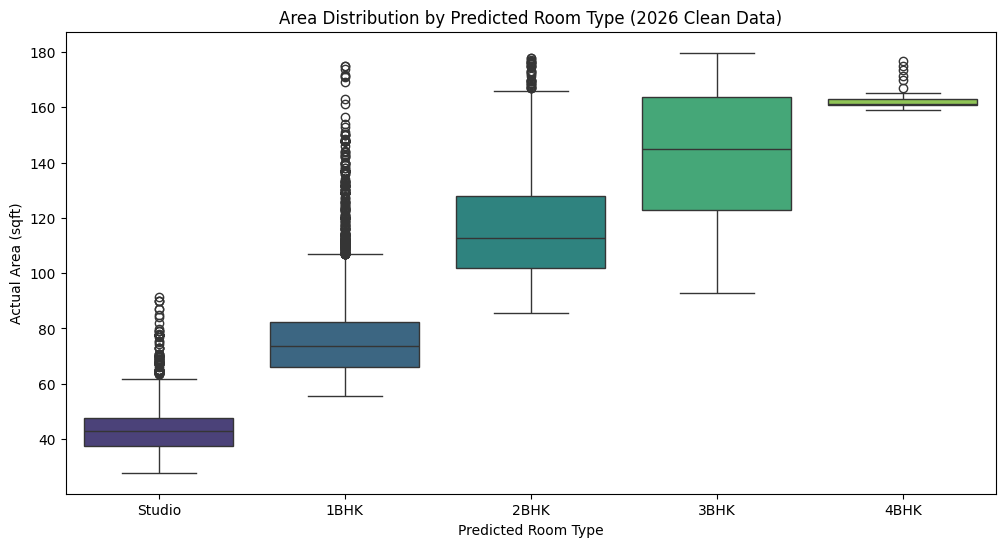

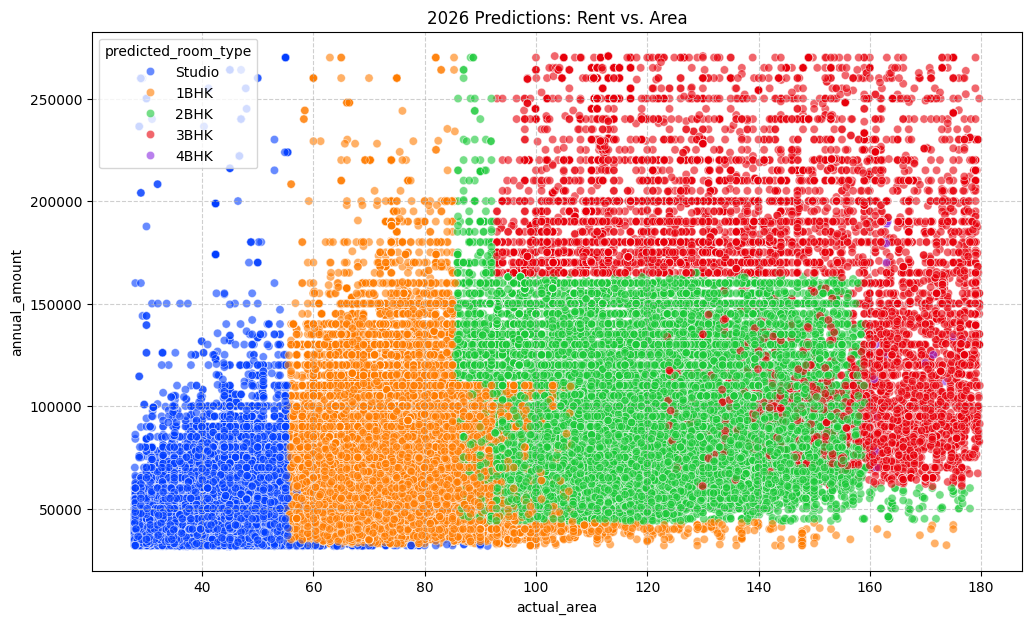

/tmp/ipykernel_2892227/1587422029.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_unit_filtered_clean, x='predicted_room_type', order=room_order, palette='magma')


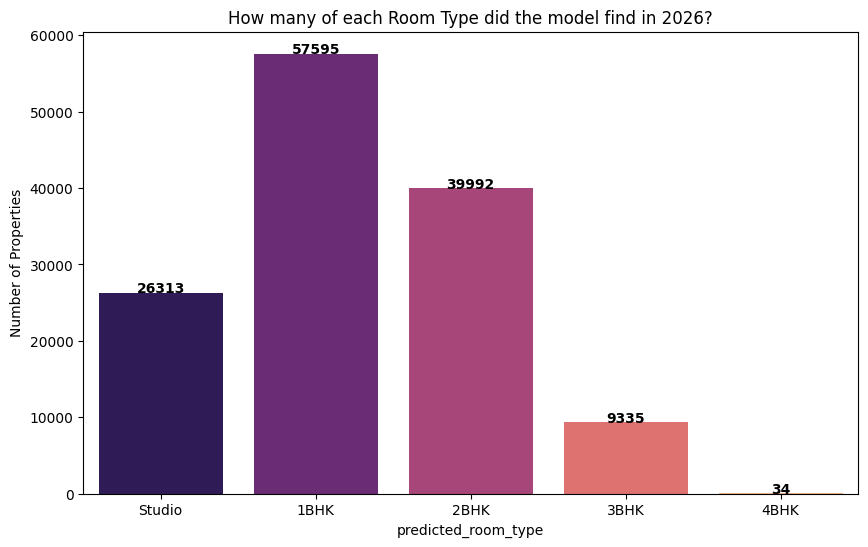

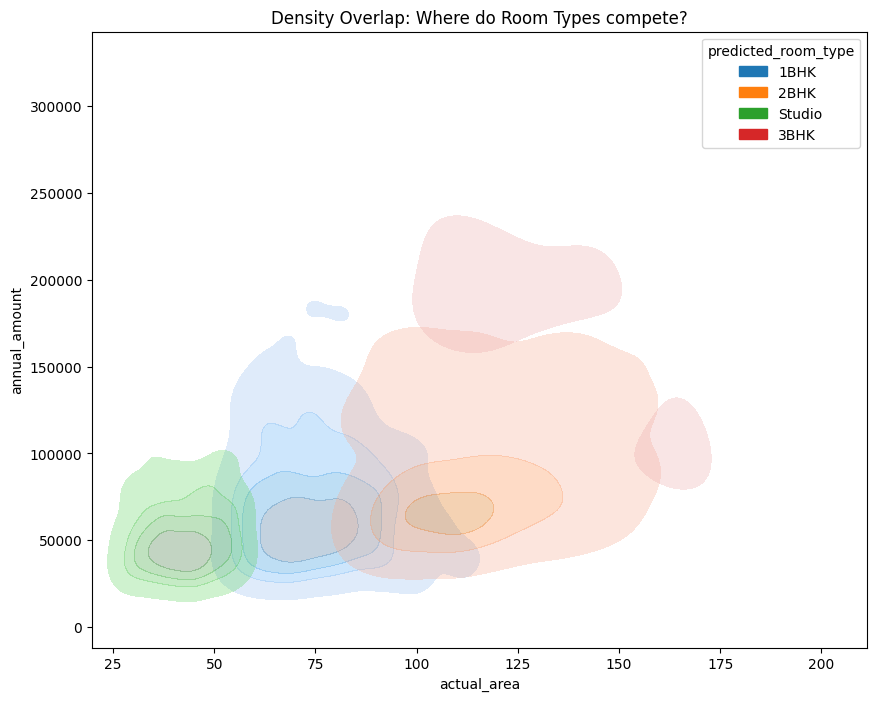

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the logical order for room types
room_order = ['Studio', '1BHK', '2BHK', '3BHK', '4BHK']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_unit_filtered_clean, x='predicted_room_type', y='actual_area', order=room_order, palette='viridis')
plt.title('Area Distribution by Predicted Room Type (2026 Clean Data)')
plt.ylabel('Actual Area (sqft)')
plt.xlabel('Predicted Room Type')
plt.show()



plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_unit_filtered_clean, x='actual_area', y='annual_amount',
                hue='predicted_room_type', hue_order=room_order, alpha=0.6, palette='bright')
plt.title('2026 Predictions: Rent vs. Area')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df_unit_filtered_clean, x='predicted_room_type', order=room_order, palette='magma')
plt.title('How many of each Room Type did the model find in 2026?')
plt.ylabel('Number of Properties')
for i, v in enumerate(df_unit_filtered_clean['predicted_room_type'].value_counts().reindex(room_order)):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')
plt.show()

# We take a sample if the data is huge to keep the plot clean
sample_df = df_unit_filtered_clean.sample(min(2000, len(df_unit_filtered_clean)))

plt.figure(figsize=(10, 8))
sns.kdeplot(data=sample_df, x='actual_area', y='annual_amount', hue='predicted_room_type',
            fill=True, alpha=0.3, levels=5)
plt.title('Density Overlap: Where do Room Types compete?')
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_unit_filtered_clean, x='predicted_room_type', y='annual_amount', marker='o', color='teal')
plt.title('Economic Sanity Check: Average annual_amount by Type')
plt.ylabel('Avg annual_amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_unit_filtered_clean, x='predicted_room_type', y='actual_area', marker='o', color='teal')
plt.title('Economic Sanity Check: Average actual_area by Type')
plt.ylabel('Avg actual_area')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# CHANGING COLUMNS NAMES


In [22]:
import pandas as pd

# 1. Define the mapping dictionary
mapping = {
    'START_DATE': 'contract_start_date',
    'END_DATE': 'contract_end_date',
    'CONTRACT_AMOUNT': 'contract_amount',
    #'ANNUAL_AMOUNT': 'annual_amount',
    'AREA_EN': 'area_name_en',
    #'IS_FREE_HOLD_EN': 'is_free_hold',
    #'ACTUAL_AREA': 'actual_area',
    'VERSION_EN' : 'contract_reg_type_en',
    'PROP_TYPE_EN': 'ejari_property_type_en',
    'PROP_SUB_TYPE_EN': 'ejari_property_sub_type_en',
    'predicted_room_type': 'room_type',
    'USAGE_EN': 'property_usage_en',
    'NEAREST_METRO_EN': 'nearest_metro_en',
    'NEAREST_MALL_EN': 'nearest_mall_en',
    'NEAREST_LANDMARK_EN': 'nearest_landmark_en',
    'TOTAL_PROPERTIES': 'no_of_prop',
    'MASTER_PROJECT_EN': 'master_project_en',
    'PROJECT_EN': 'project_name_en'
}

# 2. Rename the new dataframe columns
# Assuming df_old and df_new are your dataframes
df_new_renamed = df_unit_filtered_clean.rename(columns=mapping)



In [23]:
rental_data = pd.read_parquet('/home/ubuntu/Working_Space/data/rental_data/df_diff_2%.parquet')

In [25]:
rental_data.columns

Index(['contract_id', 'contract_reg_type_id', 'contract_reg_type_en',
       'contract_start_date', 'contract_end_date', 'contract_amount',
       'annual_amount', 'no_of_prop', 'line_number', 'is_free_hold',
       'ejari_bus_property_type_id', 'ejari_bus_property_type_en',
       'ejari_property_type_id', 'ejari_property_type_en',
       'ejari_property_sub_type_id', 'ejari_property_sub_type_en',
       'property_usage_en', 'project_number', 'project_name_en',
       'master_project_en', 'area_id', 'area_name_en', 'actual_area',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'tenant_type_id', 'tenant_type_en', 'year', 'year_reg', 'duration_days',
       'duration_years', 'room_type', 'start_year', 'duration_months', 'month',
       'day', 'weekday', 'day_name', 'monthly_amount', 'daily_amount',
       'annual_amount_calcuated', 'diff_amount', 'diff_%', 'year_str'],
      dtype='str')

In [26]:
rental_data['year_str'].value_counts()

year_str
2025    449332
2024    442863
2023    407078
2026     16063
Name: count, dtype: int64

In [31]:
cols = ['ejari_bus_property_type_en','ejari_property_type_en','ejari_property_sub_type_en','property_usage_en','room_type']

for col in cols:
    if col in rental_data.columns:
        print(f"--- Statistics for: {col} ---")
        # Added print() here to show the results
        print(rental_data[col].value_counts(normalize = True)) 
        print('+' * 50)

--- Statistics for: ejari_bus_property_type_en ---
ejari_bus_property_type_en
Unit    1.0
Name: proportion, dtype: float64
++++++++++++++++++++++++++++++++++++++++++++++++++
--- Statistics for: ejari_property_type_en ---
ejari_property_type_en
Flat    1.0
Name: proportion, dtype: float64
++++++++++++++++++++++++++++++++++++++++++++++++++
--- Statistics for: ejari_property_sub_type_en ---
ejari_property_sub_type_en
1bed room+Hall      0.417484
2 bed rooms+hall    0.337243
Studio              0.187196
3 bed rooms+hall    0.057525
4 bed rooms+hall    0.000552
Name: proportion, dtype: float64
++++++++++++++++++++++++++++++++++++++++++++++++++
--- Statistics for: property_usage_en ---
property_usage_en
Residential    1.0
Name: proportion, dtype: float64
++++++++++++++++++++++++++++++++++++++++++++++++++
--- Statistics for: room_type ---
room_type
1BHK      0.417484
2BHK      0.337243
Studio    0.187196
3BHK      0.057525
4BHK      0.000552
Name: proportion, dtype: float64
++++++++++++++++++

In [33]:
# 3. Concatenate
# 'join="outer"' keeps all columns from both.
# 'join="inner"' keeps only columns that exist in both.
df_combined = pd.concat([rental_data, df_new_renamed], axis=0, ignore_index=True)

# Optional: View the result
print(df_combined.head())

     contract_id  contract_reg_type_id contract_reg_type_en  \
0  CRT1432299706                   2.0                Renew   
1  CRT1924607536                   2.0                Renew   
2  CRT1924611426                   2.0                Renew   
3  CRT1924623096                   2.0                Renew   
4  CRT1924625596                   2.0                Renew   

   contract_start_date    contract_end_date  contract_amount  annual_amount  \
0  2023-03-01 00:00:00  2024-02-29 00:00:00          90000.0        90000.0   
1  2023-07-11 00:00:00  2024-07-10 00:00:00          30000.0        30000.0   
2  2024-07-11 00:00:00  2025-07-10 00:00:00          30000.0        30000.0   
3  2023-07-11 00:00:00  2024-07-10 00:00:00          30000.0        30000.0   
4  2024-07-11 00:00:00  2025-07-10 00:00:00          30000.0        30000.0   

   no_of_prop  line_number  is_free_hold  ...  annual_amount_calcuated  \
0           1          1.0           1.0  ...             89754.098361  

In [34]:
df_combined.isna().sum()

contract_id                    133269
contract_reg_type_id           133269
contract_reg_type_en                0
contract_start_date                 0
contract_end_date                   0
contract_amount                     0
annual_amount                       0
no_of_prop                          0
line_number                    133269
is_free_hold                   133269
ejari_bus_property_type_id     133269
ejari_bus_property_type_en     133269
ejari_property_type_id         133269
ejari_property_type_en              0
ejari_property_sub_type_id     133269
ejari_property_sub_type_en          0
property_usage_en                   0
project_number                 133269
project_name_en                 86970
master_project_en              133207
area_id                        133269
area_name_en                        0
actual_area                         0
nearest_landmark_en             10959
nearest_metro_en                18734
nearest_mall_en                 20569
tenant_type_

In [35]:
df_combined.columns

Index(['contract_id', 'contract_reg_type_id', 'contract_reg_type_en',
       'contract_start_date', 'contract_end_date', 'contract_amount',
       'annual_amount', 'no_of_prop', 'line_number', 'is_free_hold',
       'ejari_bus_property_type_id', 'ejari_bus_property_type_en',
       'ejari_property_type_id', 'ejari_property_type_en',
       'ejari_property_sub_type_id', 'ejari_property_sub_type_en',
       'property_usage_en', 'project_number', 'project_name_en',
       'master_project_en', 'area_id', 'area_name_en', 'actual_area',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'tenant_type_id', 'tenant_type_en', 'year', 'year_reg', 'duration_days',
       'duration_years', 'room_type', 'start_year', 'duration_months', 'month',
       'day', 'weekday', 'day_name', 'monthly_amount', 'daily_amount',
       'annual_amount_calcuated', 'diff_amount', 'diff_%', 'year_str',
       'REGISTRATION_DATE', 'ANNUAL_AMOUNT', 'IS_FREE_HOLD_EN', 'ACTUAL_AREA',
       'ROOMS

In [36]:
# 1. Convert the column to datetime, then extract the year
df_combined['start_year'] = pd.to_datetime(df_combined['contract_start_date']).dt.year

# 2. Check the result
print(df_combined[['contract_start_date', 'start_year']].head())

   contract_start_date  start_year
0  2023-03-01 00:00:00        2023
1  2023-07-11 00:00:00        2023
2  2024-07-11 00:00:00        2024
3  2023-07-11 00:00:00        2023
4  2024-07-11 00:00:00        2024


In [37]:
df_combined['start_year'].value_counts()

start_year
2025    449332
2024    442863
2023    407078
2026    149332
Name: count, dtype: int64

In [ ]:
cols_listed = ['area_name_en', 'actual_area',
       ]

# transactions

In [15]:
trans = pd.read_parquet('/home/ubuntu/Working_Space/data/latest_data/unit_res_trans_16.parquet')

In [39]:
trans.shape

(731198, 39)

In [40]:
trans.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'instance_date', 'property_type_id',
       'property_type_en', 'property_sub_type_id', 'property_sub_type_en',
       'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'year_month', 'year', 'month', 'day_of_week', 'day_of_year',
       'week_of_year', 'quarter'],
      dtype='str')

In [41]:
cols_lists = ['area_name_en','instance_date','rooms_en','meter_rent_price']

## latest Data

In [8]:
latest_trans = pd.read_csv('/home/ubuntu/Working_Space/data/DLD_DATA/transactions-2026-04-21.csv')

In [9]:
latest_trans.isna().sum()

TRANSACTION_NUMBER         0
INSTANCE_DATE              0
GROUP_EN                   0
PROCEDURE_EN               0
IS_OFFPLAN_EN              0
IS_FREE_HOLD_EN            0
USAGE_EN                   0
AREA_EN                    0
PROP_TYPE_EN               0
PROP_SB_TYPE_EN            0
TRANS_VALUE                0
PROCEDURE_AREA             1
ACTUAL_AREA                0
ROOMS_EN                1939
PARKING                 1448
NEAREST_METRO_EN       23960
NEAREST_MALL_EN        24725
NEAREST_LANDMARK_EN    16673
TOTAL_BUYER                0
TOTAL_SELLER               0
MASTER_PROJECT_EN      57573
PROJECT_EN              6023
dtype: int64

In [44]:
latest_trans.shape

(57842, 22)

In [45]:
latest_trans.columns

Index(['TRANSACTION_NUMBER', 'INSTANCE_DATE', 'GROUP_EN', 'PROCEDURE_EN',
       'IS_OFFPLAN_EN', 'IS_FREE_HOLD_EN', 'USAGE_EN', 'AREA_EN',
       'PROP_TYPE_EN', 'PROP_SB_TYPE_EN', 'TRANS_VALUE', 'PROCEDURE_AREA',
       'ACTUAL_AREA', 'ROOMS_EN', 'PARKING', 'NEAREST_METRO_EN',
       'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN', 'TOTAL_BUYER', 'TOTAL_SELLER',
       'MASTER_PROJECT_EN', 'PROJECT_EN'],
      dtype='str')

In [10]:
# Define the mapping for latest_trans
trans_mapping = {
    'TRANSACTION_NUMBER': 'transaction_id',
    'INSTANCE_DATE': 'instance_date',
    'GROUP_EN': 'trans_group_en',
    'PROCEDURE_EN': 'procedure_name_en',
    'USAGE_EN': 'property_usage_en',
    'AREA_EN': 'area_name_en',
    'PROP_TYPE_EN': 'property_type_en',
    'PROP_SB_TYPE_EN': 'property_sub_type_en',
    'TRANS_VALUE': 'actual_worth',
    'PROCEDURE_AREA': 'procedure_area',
    'ACTUAL_AREA': 'actual_area', # Note: 'trans' uses procedure_area, but keeping this for safety
    'ROOMS_EN': 'rooms_en',
    'PARKING': 'has_parking',
    'NEAREST_METRO_EN': 'nearest_metro_en',
    'NEAREST_MALL_EN': 'nearest_mall_en',
    'NEAREST_LANDMARK_EN': 'nearest_landmark_en',
    'MASTER_PROJECT_EN': 'master_project_en',
    'PROJECT_EN': 'project_name_en'
}

# Apply the rename
latest_trans_renamed = latest_trans.rename(columns=trans_mapping)

# Since your target list has time components, you can generate them like this:
latest_trans_renamed['instance_date'] = pd.to_datetime(latest_trans_renamed['instance_date'])
latest_trans_renamed['year'] = latest_trans_renamed['instance_date'].dt.year
latest_trans_renamed['month'] = latest_trans_renamed['instance_date'].dt.month

In [47]:
latest_trans_renamed

,transaction_id,instance_date,trans_group_en,procedure_name_en,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,property_usage_en,area_name_en,property_type_en,property_sub_type_en,...,has_parking,nearest_metro_en,nearest_mall_en,nearest_landmark_en,TOTAL_BUYER,TOTAL_SELLER,master_project_en,project_name_en,year,month
0,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK,2026,1
1,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK,2026,1
2,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK,2026,1
3,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK,2026,1
4,101-3-2026,2026-03-23 14:53:48,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,...,NaN,Business Bay Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,WEST BAY TOWER,2026,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57837,95-67-2026,2026-03-26 20:05:22,Sales,Delayed Development,Ready,Non Free Hold,Residential,SILICON OASIS,Unit,Flat,...,B-18,NaN,NaN,IMG World Adventures,0,0,NaN,UNIESTATE MILLENNIUM TOWER,2026,3
57838,95-68-2026,2026-03-31 11:15:50,Sales,Delayed Development,Ready,Non Free Hold,Residential,SILICON OASIS,Unit,Flat,...,B-20,NaN,NaN,IMG World Adventures,0,0,NaN,UNIESTATE MILLENNIUM TOWER,2026,3
57839,95-69-2026,2026-04-02 15:13:36,Sales,Delayed Development,Ready,Non Free Hold,Residential,SILICON OASIS,Unit,Flat,...,B-29,NaN,NaN,IMG World Adventures,0,0,NaN,UNIESTATE MILLENNIUM TOWER,2026,4
57840,95-7-2026,2026-01-22 10:57:01,Sales,Delayed Development,Ready,Non Free Hold,Residential,DUBAI INVESTMENT PARK SECOND,Unit,Flat,...,Building 15-1B-17,NaN,NaN,Expo 2020 Site,0,0,NaN,RITAJ,2026,1


In [11]:
latest_trans_renamed['meter_sale_price'] = latest_trans_renamed['actual_worth'] / latest_trans_renamed['procedure_area']


In [12]:
cols_required = ['meter_sale_price','rooms_en','area_name_en','instance_date']

In [50]:
latest_trans_renamed['trans_group_en'].value_counts()

trans_group_en
Sales       46630
Mortgage     9251
Gifts        1961
Name: count, dtype: int64

In [13]:
trans_latest_filtered = latest_trans_renamed[latest_trans_renamed['trans_group_en'] != 'Gifts']

In [52]:
trans_latest_filtered['trans_group_en'].value_counts()

trans_group_en
Sales       46630
Mortgage     9251
Name: count, dtype: int64

In [53]:
trans_latest_filtered['rooms_en'].value_counts()

rooms_en
1 B/R        22440
2 B/R        14210
Studio       12220
3 B/R         3635
Office         899
4 B/R          381
Shop           144
5 B/R           49
6 B/R           13
PENTHOUSE       13
Hotel            1
Name: count, dtype: int64

In [16]:
# 1. Define the columns you want to keep
cols_required = ['meter_sale_price','actual_worth', 'rooms_en', 'area_name_en', 'instance_date']

# 2. Subset both dataframes to only include those columns
# This ensures that when you concatenate, you don't end up with dozens of NaN columns
df1_subset = trans[cols_required]
df2_subset = trans_latest_filtered[cols_required]

# 3. Combine them vertically
df_final_transactions = pd.concat([df1_subset, df2_subset], axis=0, ignore_index=True)

# 4. Verification
print(f"Total rows: {len(df_final_transactions)}")
print(df_final_transactions.head())

Total rows: 787079
   meter_sale_price  actual_worth rooms_en        area_name_en instance_date
0          51665.31     5693000.0    2 B/R  Trade Center First    2026-01-08
1          45794.84     9962667.0    2 B/R             Al Wasl    2025-04-30
2          64583.41    97165740.0    4 B/R             Al Wasl    2023-02-09
3          61551.05    18077542.0    3 B/R             Al Wasl    2025-04-30
4          11953.35     1025000.0    1 B/R      Rega Al Buteen    2016-02-15


In [55]:
df_final_transactions.shape

(787079, 4)

In [20]:
df_final_transactions.to_csv('latest_cmb_trans.csv')

In [69]:
# 1. Calculate Median Transaction Price (from the transactions data)
trans_stats = df_final_transactions.groupby(['area_name_en', 'rooms_en'])['actual_worth'].median().reset_index()
trans_stats.rename(columns={'actual_worth': 'median_transaction_amount'}, inplace=True)

# 2. Calculate Median Annual Rent (from the rental data)
# Note: Using 'annual_amount' from your df_combined
rent_stats = df_combined.groupby(['area_name_en', 'room_type'])['annual_amount'].median().reset_index()
rent_stats.rename(columns={'room_type': 'rooms_en', 'annual_amount': 'median_annual_rent'}, inplace=True)

# 3. Merge the two datasets on Area and Room Type
yield_df = pd.merge(rent_stats, trans_stats, on=['area_name_en', 'rooms_en'], how='inner')

# 4. Apply your formula: (Rent / Transaction Amt) * 100
yield_df['rental_yield_yearly'] = (yield_df['median_annual_rent'] / yield_df['median_transaction_amount']) * 100

# 5. Display the result
print(yield_df.head())

              area_name_en rooms_en  median_annual_rent  \
0          Al Barsha First   Studio             42000.0   
1    Al Barsha South Fifth   Studio             42000.0   
2   Al Barsha South Fourth   Studio             45000.0   
3  Al Barshaa South Second   Studio             42000.0   
4   Al Barshaa South Third   Studio             42000.0   

   median_transaction_amount  rental_yield_yearly  
0                   750000.0             5.600000  
1                   597205.0             7.032761  
2                   555000.0             8.108108  
3                   800000.0             5.250000  
4                   515000.0             8.155340  


In [58]:
yield_df.sort_values(by = ['area_name_en','rooms_en'] )

,area_name_en,rooms_en,median_annual_rent,median_transaction_amount,rental_yield_yearly
0,Al Barsha First,Studio,42000.0,15404.410000,272.649196
1,Al Barsha South Fifth,Studio,42000.0,17138.300000,245.065146
2,Al Barsha South Fourth,Studio,45000.0,13853.050000,324.838213
3,Al Barshaa South Second,Studio,42000.0,18836.850000,222.967216
4,Al Barshaa South Third,Studio,42000.0,13602.520000,308.766317
5,Al Goze Fourth,Studio,35000.0,7940.210000,440.794387
6,Al Hebiah Fifth,Studio,36750.0,11442.890000,321.160127
7,Al Hebiah First,Studio,43000.0,13261.900000,324.237100
8,Al Hebiah Fourth,Studio,36000.0,10551.560000,341.181778
9,Al Hebiah Second,Studio,47000.0,15036.140000,312.580223


In [59]:
# 1. Align room naming conventions first
# This ensures "1BHK" in rental data matches "1 B/R" in transaction data
room_map = {'Studio': 'Studio', '1BHK': '1 B/R', '2BHK': '2 B/R', '3BHK': '3 B/R', '4BHK': '4 B/R'}
df_combined['room_type_aligned'] = df_combined['room_type'].map(room_map)

# 2. Aggregate Rental Data (Median, Min, Max)
rent_stats = df_combined.groupby(['area_name_en', 'room_type_aligned'])['annual_amount'].agg(
    median_annual_rent='median',
    min_annual_rent='min',
    max_annual_rent='max'
).reset_index()
rent_stats.rename(columns={'room_type_aligned': 'rooms_en'}, inplace=True)

# 3. Aggregate Transaction Data (Median)
trans_stats = df_final_transactions.groupby(['area_name_en', 'rooms_en'])['meter_sale_price'].median().reset_index()
trans_stats.rename(columns={'meter_sale_price': 'median_transaction_amount'}, inplace=True)

# 4. Merge the datasets
yield_df = pd.merge(rent_stats, trans_stats, on=['area_name_en', 'rooms_en'], how='inner')

# 5. Calculate Rental Yield
yield_df['rental_yield_percentage'] = (yield_df['median_annual_rent'] / yield_df['median_transaction_amount']) * 100

# 6. Display results
print(yield_df[['area_name_en', 'rooms_en', 'min_annual_rent', 'median_annual_rent', 'max_annual_rent', 'rental_yield_percentage']].head())

            area_name_en rooms_en  min_annual_rent  median_annual_rent  \
0        Al Barsha First    1 B/R           5000.0             58212.0   
1        Al Barsha First    2 B/R           9000.0             80000.0   
2        Al Barsha First    3 B/R          12000.0            109200.0   
3        Al Barsha First   Studio           5000.0             42000.0   
4  Al Barsha South Fifth    1 B/R          12000.0             60000.0   

   max_annual_rent  rental_yield_percentage  
0         288716.0               418.829031  
1         450000.0               600.843735  
2         250000.0               619.435644  
3         140000.0               272.649196  
4         176000.0               407.658822  


In [60]:
# 1. Define the numeric mapping
# This serves dual purpose: aligning names and creating a sortable ID
room_id_map = {
    'Studio': 0, 
    '1BHK': 1, '1 B/R': 1, 
    '2BHK': 2, '2 B/R': 2, 
    '3BHK': 3, '3 B/R': 3, 
    '4BHK': 4, '4 B/R': 4
}

# 2. Assign Room IDs to both DataFrames before grouping
df_combined['room_id'] = df_combined['room_type'].map(room_id_map)
df_final_transactions['room_id'] = df_final_transactions['rooms_en'].map(room_id_map)

# 3. Aggregate Rental Data (Median, Min, Max) using room_id
rent_stats = df_combined.groupby(['area_name_en', 'room_id'])['annual_amount'].agg(
    median_annual_rent='median',
    min_annual_rent='min',
    max_annual_rent='max'
).reset_index()

# 4. Aggregate Transaction Data (Median) using room_id
trans_stats = df_final_transactions.groupby(['area_name_en', 'room_id'])['meter_sale_price'].median().reset_index()
trans_stats.rename(columns={'meter_sale_price': 'median_transaction_amount'}, inplace=True)

# 5. Merge the datasets on area and room_id
yield_df = pd.merge(rent_stats, trans_stats, on=['area_name_en', 'room_id'], how='inner')

# 6. Calculate Rental Yield and bring back the readable room name for the report
yield_df['rental_yield_percentage'] = (yield_df['median_annual_rent'] / yield_df['median_transaction_amount']) * 100

# Create a reverse map to get labels back (optional, but good for display)
id_to_label = {0: 'Studio', 1: '1 BHK', 2: '2 BHK', 3: '3 BHK', 4: '4 BHK'}
yield_df['rooms_en'] = yield_df['room_id'].map(id_to_label)

# 7. Final Sort and Display
yield_df = yield_df.sort_values(by=['area_name_en', 'room_id']).reset_index(drop=True)

cols_to_show = ['area_name_en', 'room_id', 'rooms_en', 'min_annual_rent', 
                'median_annual_rent', 'max_annual_rent', 'rental_yield_percentage']

print(yield_df[cols_to_show].head(10))

             area_name_en  room_id rooms_en  min_annual_rent  \
0         Al Barsha First        0   Studio           5000.0   
1         Al Barsha First        1    1 BHK           5000.0   
2         Al Barsha First        2    2 BHK           9000.0   
3         Al Barsha First        3    3 BHK          12000.0   
4   Al Barsha South Fifth        0   Studio          10000.0   
5   Al Barsha South Fifth        1    1 BHK          12000.0   
6   Al Barsha South Fifth        2    2 BHK           5225.0   
7   Al Barsha South Fifth        3    3 BHK          75000.0   
8  Al Barsha South Fourth        0   Studio              0.0   
9  Al Barsha South Fourth        1    1 BHK              1.0   

   median_annual_rent  max_annual_rent  rental_yield_percentage  
0             42000.0         140000.0               272.649196  
1             58212.0         288716.0               418.829031  
2             80000.0         450000.0               600.843735  
3            109200.0         2

In [61]:
yield_df

,area_name_en,room_id,median_annual_rent,min_annual_rent,max_annual_rent,median_transaction_amount,rental_yield_percentage,rooms_en
0,Al Barsha First,0,42000.0,5000.0,140000.0,15404.410,272.649196,Studio
1,Al Barsha First,1,58212.0,5000.0,288716.0,13898.750,418.829031,1 BHK
2,Al Barsha First,2,80000.0,9000.0,450000.0,13314.610,600.843735,2 BHK
3,Al Barsha First,3,109200.0,12000.0,250000.0,17628.950,619.435644,3 BHK
4,Al Barsha South Fifth,0,42000.0,10000.0,120000.0,17138.300,245.065146,Studio
...,...,...,...,...,...,...,...,...
255,Zaabeel First,2,475000.0,160000.0,1000000.0,28196.080,1684.631339,2 BHK
256,Zaabeel First,3,270000.0,270000.0,270000.0,28599.755,944.064031,3 BHK
257,Zaabeel Second,1,120000.0,5000.0,200000.0,24270.570,494.425965,1 BHK
258,Zaabeel Second,2,172000.0,6565.0,330000.0,23203.700,741.261092,2 BHK


In [62]:
# 1. Define the numeric mapping
room_id_map = {
    'Studio': 0, '1BHK': 1, '1 B/R': 1, 
    '2BHK': 2, '2 B/R': 2, 
    '3BHK': 3, '3 B/R': 3, 
    '4BHK': 4, '4 B/R': 4
}

# 2. Assign Room IDs
df_combined['room_id'] = df_combined['room_type'].map(room_id_map)
df_final_transactions['room_id'] = df_final_transactions['rooms_en'].map(room_id_map)

# 3. Aggregate Rental Data by Year, Area, and Room ID
# Note: Using 'start_year' from cell [36]
rent_stats_yearly = df_combined.groupby(['start_year', 'area_name_en', 'room_id'])['annual_amount'].agg(
    median_annual_rent='median',
    min_annual_rent='min',
    max_annual_rent='max'
).reset_index()
rent_stats_yearly.rename(columns={'start_year': 'year'}, inplace=True)

# 4. Aggregate Transaction Data by Year, Area, and Room ID
trans_stats_yearly = df_final_transactions.groupby(['year', 'area_name_en', 'room_id'])['meter_sale_price'].median().reset_index()
trans_stats_yearly.rename(columns={'meter_sale_price': 'median_transaction_amount'}, inplace=True)

# 5. Merge on Year, Area, and Room ID
yield_df_yearly = pd.merge(
    rent_stats_yearly, 
    trans_stats_yearly, 
    on=['year', 'area_name_en', 'room_id'], 
    how='inner'
)

# 6. Calculate Yield
yield_df_yearly['rental_yield_percentage'] = (yield_df_yearly['median_annual_rent'] / yield_df_yearly['median_transaction_amount']) * 100

# 7. Final Formatting and Sorting
id_to_label = {0: 'Studio', 1: '1 BHK', 2: '2 BHK', 3: '3 BHK', 4: '4 BHK'}
yield_df_yearly['rooms_en'] = yield_df_yearly['room_id'].map(id_to_label)

yield_df_yearly = yield_df_yearly.sort_values(by=['year', 'area_name_en', 'room_id'], ascending=[False, True, True]).reset_index(drop=True)

# 8. Display result
cols_to_show = ['year', 'area_name_en', 'rooms_en', 'min_annual_rent', 'median_annual_rent', 'max_annual_rent', 'rental_yield_percentage']
print(yield_df_yearly[cols_to_show].head(15))

KeyError: 'year'

In [64]:
# 1. Prepare Year column for Rental Data (if not already done)
if 'contract_start_date' in df_combined.columns:
    df_combined['year'] = pd.to_datetime(df_combined['contract_start_date']).dt.year

# 2. Prepare Year column for Transaction Data
# Extract year from 'instance_date' to match the groupby key
if 'instance_date' in df_final_transactions.columns:
    df_final_transactions['year'] = pd.to_datetime(df_final_transactions['instance_date']).dt.year

# 3. Define the numeric mapping
room_id_map = {
    'Studio': 0, '1BHK': 1, '1 B/R': 1, 
    '2BHK': 2, '2 B/R': 2, 
    '3BHK': 3, '3 B/R': 3, 
    '4BHK': 4, '4 B/R': 4
}

# 4. Assign Room IDs
df_combined['room_id'] = df_combined['room_type'].map(room_id_map)
df_final_transactions['room_id'] = df_final_transactions['rooms_en'].map(room_id_map)

# 5. Aggregate Rental Data by Year, Area, and Room ID
rent_stats_yearly = df_combined.groupby(['year', 'area_name_en', 'room_id'])['annual_amount'].agg(
    median_annual_rent='median',
    min_annual_rent='min',
    max_annual_rent='max'
).reset_index()

# 6. Aggregate Transaction Data by Year, Area, and Room ID
trans_stats_yearly = df_final_transactions.groupby(['year', 'area_name_en', 'room_id'])['actual_worth'].median().reset_index()
trans_stats_yearly.rename(columns={'meter_sale_price': 'median_transaction_amount'}, inplace=True)

# 7. Merge on Year, Area, and Room ID
yield_df_yearly = pd.merge(
    rent_stats_yearly, 
    trans_stats_yearly, 
    on=['year', 'area_name_en', 'room_id'], 
    how='inner'
)

# 8. Calculate Yield and Final Formatting
yield_df_yearly['rental_yield_percentage'] = (yield_df_yearly['median_annual_rent'] / yield_df_yearly['median_transaction_amount']) * 100

id_to_label = {0: 'Studio', 1: '1 BHK', 2: '2 BHK', 3: '3 BHK', 4: '4 BHK'}
yield_df_yearly['rooms_en'] = yield_df_yearly['room_id'].map(id_to_label)

yield_df_yearly = yield_df_yearly.sort_values(by=['year', 'area_name_en', 'room_id'], ascending=[False, True, True]).reset_index(drop=True)

print(yield_df_yearly.head(15))

KeyError: 'Column not found: actual_worth'

# combining data sets

In [72]:
# 1. Update columns to include 'actual_worth'
cols_required = ['actual_worth', 'rooms_en', 'area_name_en', 'instance_date']

# 2. Re-create the combined transaction dataframe with the correct columns
df1_subset = trans[cols_required]
df2_subset = trans_latest_filtered[cols_required]
df_final_transactions = pd.concat([df1_subset, df2_subset], axis=0, ignore_index=True)

# 3. Create Year and Room ID columns
df_combined['year'] = pd.to_datetime(df_combined['contract_start_date']).dt.year
df_final_transactions['year'] = pd.to_datetime(df_final_transactions['instance_date']).dt.year

room_id_map = {
    'Studio': 0, '1BHK': 1, '1 B/R': 1, 
    '2BHK': 2, '2 B/R': 2, 
    '3BHK': 3, '3 B/R': 3, 
    '4BHK': 4, '4 B/R': 4
}
df_combined['room_id'] = df_combined['room_type'].map(room_id_map)
df_final_transactions['room_id'] = df_final_transactions['rooms_en'].map(room_id_map)

# 4. Aggregate Rental Data
rent_stats_yearly = df_combined.groupby(['year', 'area_name_en', 'room_id'])['annual_amount'].agg(
    median_annual_rent='median',
    min_annual_rent='min',
    max_annual_rent='max'
).reset_index()

# 5. Aggregate Transaction Data using ACTUAL WORTH
trans_stats_yearly = df_final_transactions.groupby(['year', 'area_name_en', 'room_id'])['actual_worth'].median().reset_index()
trans_stats_yearly.rename(columns={'actual_worth': 'median_transaction_amount'}, inplace=True)

# 6. Merge and Calculate Yield
yield_df_yearly = pd.merge(rent_stats_yearly, trans_stats_yearly, on=['year', 'area_name_en', 'room_id'], how='inner')
yield_df_yearly['rental_yield_percentage'] = ((yield_df_yearly['median_annual_rent'] / yield_df_yearly['median_transaction_amount']) * 100).round()

# 7. Final Formatting
id_to_label = {0: 'Studio', 1: '1 BHK', 2: '2 BHK', 3: '3 BHK', 4: '4 BHK'}
yield_df_yearly['rooms_en'] = yield_df_yearly['room_id'].map(id_to_label)
yield_df_yearly = yield_df_yearly.sort_values(by=['year', 'area_name_en', 'room_id'], ascending=[False, True, True]).reset_index(drop=True)

print(yield_df_yearly.head(15))

    year             area_name_en  room_id  median_annual_rent  \
0   2026          Al Barsha First        0             55000.0   
1   2026          Al Barsha First        1             67000.0   
2   2026          Al Barsha First        2             85000.0   
3   2026          Al Barsha First        3            113620.0   
4   2026    Al Barsha South Fifth        0             50000.0   
5   2026    Al Barsha South Fifth        1             75000.0   
6   2026    Al Barsha South Fifth        2             87575.0   
7   2026    Al Barsha South Fifth        3            125000.0   
8   2026   Al Barsha South Fourth        0             52000.0   
9   2026   Al Barsha South Fourth        1             73500.0   
10  2026   Al Barsha South Fourth        2             90000.0   
11  2026   Al Barsha South Fourth        3            139000.0   
12  2026  Al Barshaa South Second        0             50000.0   
13  2026  Al Barshaa South Second        1             70000.0   
14  2026  

In [74]:
yield_df_yearly['area_name_en'].nunique()

68

In [75]:
yield_df_yearly.to_csv('dubai_market_yield_report.csv')

# YOY 
* Area wise and rooms wise


  $$\text{YoY \%} = \frac{\text{Current} - \text{Previous}}{\text{Previous}} \times 100$$

In [21]:
latest_trans = pd.read_csv('latest_cmb_trans.csv')


In [23]:
latest_trans.sample(10)

,Unnamed: 0,meter_sale_price,actual_worth,rooms_en,area_name_en,instance_date
103858,103858,5381.840000,1000000.0,2 B/R,Al Hebiah First,2025-01-31
111867,111867,12054.610000,437100.0,Studio,Al Barshaa South Third,2017-05-25
76370,76370,22343.030000,1684888.0,1 B/R,Burj Khalifa,2019-05-29
62297,62297,10484.580000,357000.0,Studio,Madinat Al Mataar,2018-11-08
221837,221837,19985.850000,735079.0,Studio,Wadi Al Safa 5,2025-04-15
458055,458055,34390.580000,15629487.0,4 B/R,Burj Khalifa,2023-06-22
694086,694086,11680.140000,1300000.0,1 B/R,Marsa Dubai,2018-07-18
385772,385772,18101.590000,819821.0,1 B/R,Hadaeq Sheikh Mohammed Bin Rashid,2024-02-29
736691,736691,15345.043915,1223000.0,1 B/R,Jabal Ali First,2026-02-11 14:33:00
751153,751153,18302.192144,1244000.0,1 B/R,Al Hebiah Fifth,2026-03-30 13:45:12


In [27]:
latest_trans['instance_date'] 

0        2026-01-08 00:00:00
1        2025-04-30 00:00:00
2        2023-02-09 00:00:00
3        2025-04-30 00:00:00
4        2016-02-15 00:00:00
                 ...        
787074   2026-03-26 20:05:22
787075   2026-03-31 11:15:50
787076   2026-04-02 15:13:36
787077   2026-01-22 10:57:01
787078   2026-01-23 09:39:11
Name: instance_date, Length: 787079, dtype: datetime64[us]

In [28]:
# 1. Convert to datetime objects first (handling mixed formats)
latest_trans['instance_date'] = pd.to_datetime(latest_trans['instance_date'], format='mixed', errors='coerce')

# 2. Extract Year for grouping (integer/numeric is better for sorting)
latest_trans['year'] = latest_trans['instance_date'].dt.year

# 3. Format the date column to standard YYYY-mm-dd string format
latest_trans['instance_date'] = latest_trans['instance_date'].dt.strftime('%Y-%m-%d')

# 4. Group by Area, Room, and Year to find the Median Meter Sale Price
yoy_stats = latest_trans.groupby(['area_name_en', 'rooms_en', 'year'])['meter_sale_price'].median().reset_index()

# 5. Sort for YoY calculation
yoy_stats = yoy_stats.sort_values(['area_name_en', 'rooms_en', 'year'])

# 6. Calculate YoY Growth Percentage
yoy_stats['prev_year_median_meter_price'] = yoy_stats.groupby(['area_name_en', 'rooms_en'])['meter_sale_price'].shift(1)
yoy_stats['yoy_growth_%'] = ((yoy_stats['meter_sale_price'] - yoy_stats['prev_year_median_meter_price']) / yoy_stats['prev_year_median_meter_price'] * 100).round(2)

# 7. Filter for recent years
yoy_report = yoy_stats[yoy_stats['year'] >= 2023].copy()

# 8. Clean up Infinity and display
import numpy as np
yoy_report['yoy_growth_%'] = yoy_report['yoy_growth_%'].replace([np.inf, -np.inf], np.nan)

print(yoy_report.head(20))

        area_name_en rooms_en  year  meter_sale_price  \
0          AL BARARI    1 B/R  2026      18710.197510   
1          AL BARARI    2 B/R  2026      26316.038202   
2          AL BARARI    3 B/R  2026      31211.993768   
3          AL BARARI    4 B/R  2026      34572.418191   
4          AL BARARI   Studio  2026      18710.196488   
5          AL FURJAN    1 B/R  2026      13492.843876   
6          AL FURJAN    2 B/R  2026      12596.995864   
7          AL FURJAN    3 B/R  2026      12455.807977   
8          AL FURJAN    4 B/R  2026      13406.065089   
9          AL FURJAN     Shop  2026      26371.483391   
10         AL FURJAN   Studio  2026      14726.706315   
11  AL KHAIL HEIGHTS    1 B/R  2026       8779.631255   
12  AL KHAIL HEIGHTS    2 B/R  2026       8616.562949   
13  AL KHAIL HEIGHTS    4 B/R  2026       4150.077869   
14  AL KHAIL HEIGHTS    5 B/R  2026       3726.111039   
15  AL KHAIL HEIGHTS    6 B/R  2026       3505.706901   
16  AL KHAIL HEIGHTS   Studio  

In [33]:
import pandas as pd
import numpy as np

# 1. Load the data (Ensure this matches your current dataframe name)
# latest_trans = pd.read_csv('latest_cmb_trans.csv') 

# 2. Standardize dates and extract year
# We use format='mixed' to handle the various date formats in your DLD data
latest_trans['instance_date'] = pd.to_datetime(latest_trans['instance_date'], format='mixed', errors='coerce')
latest_trans['year'] = latest_trans['instance_date'].dt.year
latest_trans['year'].value_counts()

year
2025    190437
2024    156548
2023    106695
2022     71418
2026     66429
2021     43964
2017     36265
2016     32986
2019     29872
2018     27406
2020     25059
Name: count, dtype: int64

In [31]:

# 3. Format the date column to standard YYYY-mm-dd
latest_trans['instance_date'] = latest_trans['instance_date'].dt.strftime('%Y-%m-%d')

# 4. Group by Area, Room, and Year to get the Median Meter Sale Price
# Note: We group the WHOLE dataset so that 2026 can see 2025, 2025 can see 2024, etc.
yoy_stats = latest_trans.groupby(['area_name_en', 'rooms_en', 'year'])['meter_sale_price'].median().reset_index()

# 5. Sort the data - CRITICAL for the shift function to work correctly
yoy_stats = yoy_stats.sort_values(['area_name_en', 'rooms_en', 'year'])

# 6. Calculate the Previous Year's Price and YoY Growth
# The groupby ensures we only compare the same area and room type
yoy_stats['prev_year_median_meter_price'] = yoy_stats.groupby(['area_name_en', 'rooms_en'])['meter_sale_price'].shift(1)

# Apply the YoY percentage formula
yoy_stats['yoy_growth_%'] = (
    (yoy_stats['meter_sale_price'] - yoy_stats['prev_year_median_meter_price']) / 
    yoy_stats['prev_year_median_meter_price'] * 100
).round(2)

# 7. Clean up infinity values (if previous year was 0)
yoy_stats['yoy_growth_%'] = yoy_stats['yoy_growth_%'].replace([np.inf, -np.inf], np.nan)

# 8. Filter the final report for years 2023 and onwards
# Since we shifted BEFORE filtering, 2023 will now correctly show growth vs 2022
yoy_report = yoy_stats[yoy_stats['year'] >= 2023].copy()

# 9. Final check: Sort by Area and Year for a clean view
yoy_report = yoy_report.sort_values(['area_name_en', 'year', 'rooms_en'])

# Display the top 20 rows
print(yoy_report.head(20))

# Optional: Save to CSV
# yoy_report.to_csv('yoy_meter_price_report_2023_2026.csv', index=False)

        area_name_en rooms_en  year  meter_sale_price  \
0          AL BARARI    1 B/R  2026      18710.197510   
1          AL BARARI    2 B/R  2026      26316.038202   
2          AL BARARI    3 B/R  2026      31211.993768   
3          AL BARARI    4 B/R  2026      34572.418191   
4          AL BARARI   Studio  2026      18710.196488   
5          AL FURJAN    1 B/R  2026      13492.843876   
6          AL FURJAN    2 B/R  2026      12596.995864   
7          AL FURJAN    3 B/R  2026      12455.807977   
8          AL FURJAN    4 B/R  2026      13406.065089   
9          AL FURJAN     Shop  2026      26371.483391   
10         AL FURJAN   Studio  2026      14726.706315   
11  AL KHAIL HEIGHTS    1 B/R  2026       8779.631255   
12  AL KHAIL HEIGHTS    2 B/R  2026       8616.562949   
13  AL KHAIL HEIGHTS    4 B/R  2026       4150.077869   
14  AL KHAIL HEIGHTS    5 B/R  2026       3726.111039   
15  AL KHAIL HEIGHTS    6 B/R  2026       3505.706901   
16  AL KHAIL HEIGHTS   Studio  

In [34]:
yoy_report.sample(20)

,area_name_en,rooms_en,year,meter_sale_price,prev_year_median_meter_price,yoy_growth_%
941,Al Thanyah Fifth,1 B/R,2025,20354.725000,16623.670,22.44
437,Al Hebiah Fourth,4 B/R,2025,7634.590000,3732.465,104.55
983,Al Thanyah Fifth,5 B/R,2024,10510.220000,21980.815,-52.18
1515,DUBAI INDUSTRIAL CITY,Studio,2026,16145.869086,NaN,NaN
572,Al Jadaf,1 B/R,2023,13916.180000,11595.550,20.01
2740,Ras Al Khor Industrial First,5 B/R,2024,25833.400000,NaN,NaN
1036,Al Thanyah First,3 B/R,2024,7393.570000,5958.590,24.08
2512,Nad Al Shiba First,1 B/R,2023,13303.535000,11071.280,20.16
2789,SUFOUH GARDENS,Studio,2026,17214.571302,NaN,NaN
152,Al Barsha South Fourth,PENTHOUSE,2025,5224.440000,5902.800,-11.49


In [38]:
yoy_report[(yoy_report['year'] == 2026) & ].sort_values(by = 'yoy_growth_%')

,area_name_en,rooms_en,year,meter_sale_price,prev_year_median_meter_price,yoy_growth_%
1816,Island 2,3 B/R,2026,18952.010000,144312.040,-86.87
1423,Business Bay,3 B/R,2026,8677.625406,22627.980,-61.65
2768,Rega Al Buteen,3 B/R,2026,4792.628015,9456.635,-49.32
1988,Jabal Ali Industrial Second,3 B/R,2026,7986.570000,14987.850,-46.71
2451,Muhaisanah First,3 B/R,2026,8540.418099,15069.320,-43.33
...,...,...,...,...,...,...
2838,TOWN SQUARE,Studio,2026,15313.368324,NaN,NaN
2845,Trade Center First,Office,2026,19884.251248,NaN,NaN
3145,Warsan First,1 B/R,2026,12017.184035,NaN,NaN
3146,Warsan First,2 B/R,2026,9582.113388,NaN,NaN


In [39]:
yoy_report.columns

Index(['area_name_en', 'rooms_en', 'year', 'meter_sale_price',
       'prev_year_median_meter_price', 'yoy_growth_%'],
      dtype='str')

In [44]:
cols = ['area_name_en', 'rooms_en', 'year','yoy_growth_%' ] 
cleaned_df = yoy_report[cols]
cleaned_df[cleaned_df['yoy_growth_%'].isna()]['area_name_en'].unique()

<ArrowStringArray>
[              'AL BARARI',               'AL FURJAN',
        'AL KHAIL HEIGHTS',                 'AL WAHA',
                   'ARJAN',         'Al Barsha First',
   'Al Barsha South Fifth', 'Al Barshaa South Second',
         'Al Hebiah First',        'Al Khairan First',
 ...
               'THE LAKES',               'THE WORLD',
             'TOWN SQUARE',      'Trade Center First',
          'Wadi Al Safa 3',          'Wadi Al Safa 4',
          'Wadi Al Safa 5',            'Warsan First',
           'Zaabeel First',          'Zaabeel Second']
Length: 113, dtype: str

In [46]:
import pandas as pd 

df = pd.read_csv('dubai_market_yield_report.csv')

In [47]:
df

,Unnamed: 0,year,area_name_en,room_id,median_annual_rent,min_annual_rent,max_annual_rent,median_transaction_amount,rental_yield_percentage,rooms_en
0,0,2026,Al Barsha First,0,55000.0,33000.0,140000.0,750000.0,7.0,Studio
1,1,2026,Al Barsha First,1,67000.0,32000.0,220000.0,1870758.0,4.0,1 BHK
2,2,2026,Al Barsha First,2,85000.0,40000.0,155000.0,2805894.0,3.0,2 BHK
3,3,2026,Al Barsha First,3,113620.0,76707.0,250000.0,4075111.0,3.0,3 BHK
4,4,2026,Al Barsha South Fifth,0,50000.0,32600.0,90000.0,777500.0,6.0,Studio
...,...,...,...,...,...,...,...,...,...,...
890,890,2023,Warsan Fourth,1,36000.0,5000.0,65577.0,506000.0,7.0,1 BHK
891,891,2023,Warsan Fourth,2,50000.0,10000.0,90000.0,619200.0,8.0,2 BHK
892,892,2023,Zaabeel Second,1,110000.0,10000.0,177377.0,1984000.0,6.0,1 BHK
893,893,2023,Zaabeel Second,2,160000.0,15000.0,330000.0,2900000.0,6.0,2 BHK


In [48]:
df['area_name_en'].nunique()

68